Exploring different graph level learning models - GAT

In [1]:
import torch
from torch_geometric.data import Data
import os

# Define the path where the patient graphs are stored
graphs_dir = '../PreprocessingScripts/PatientGraphs/StaticEdge/'

# Initialize a dictionary to store the graphs
patient_graphs = {}

# Loop through the files in the directory and load each graph
for file_name in os.listdir(graphs_dir):
    if file_name.endswith('.pt'):
        # Get the patient identifier (e.g., 'patient_1', 'patient_2', etc.)
        patient_id = file_name.split('.')[0]
        
        # Load the graph (PyTorch Geometric graph object)
        graph = torch.load(os.path.join(graphs_dir, file_name))
        
        # Add the graph to the dictionary
        patient_graphs[patient_id] = graph
        #print(graph.edge_attr.shape)

# Now `patient_graphs` contains all the loaded graphs, accessible by patient IDs


/tmp/ipykernel_101863/1231427283.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load(os.path.join(graphs_dir, file_name))


In [2]:
graph = torch.load('../PreprocessingScripts/Sample 1_graph.pt')

/tmp/ipykernel_101863/1209562805.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load('../PreprocessingScripts/Sample 1_graph.pt')


In [3]:
import torch
import networkx as nx

# Load the graph
graph = torch.load('../PreprocessingScripts/Sample 1_graph.pt')

edges = graph.edge_index.t().numpy() 
G = nx.Graph()
G.add_edges_from(edges)

if nx.is_connected(G): 
    diameter = nx.diameter(G)
    print("Diameter of the graph:", diameter)
else:
    print("The graph is not connected, so the diameter is undefined.")


if nx.is_connected(G):
    avg_shortest_path_length = nx.average_shortest_path_length(G)
    print(f"Average Shortest Path Length: {avg_shortest_path_length}")
else:
    print("The graph is not connected.")


/tmp/ipykernel_101863/3415228665.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load('../PreprocessingScripts/Sample 1_graph.pt')


Diameter of the graph: 7
Average Shortest Path Length: 2.715840602890814


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import dropout_adj
import numpy as np

class AttentionReadout(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.att = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.Tanh(),
            nn.Linear(feat_dim, 1)
        )

    def forward(self, x):
        att_logits = self.att(x)
        att_weights = torch.softmax(att_logits, dim=0)
        return torch.sum(att_weights * x, dim=0)

class GATEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_heads):
        super().__init__()
        self.dropout = 0.5
        self.gat1 = GATConv(in_channels, hidden_channels, heads=num_heads, dropout=self.dropout)
        self.bn1 = nn.BatchNorm1d(hidden_channels * num_heads)
        self.gat2 = GATConv(hidden_channels * num_heads, hidden_channels, heads=num_heads, dropout=self.dropout)
        self.bn2 = nn.BatchNorm1d(hidden_channels * num_heads)
        self.gat3 = GATConv(hidden_channels * num_heads, out_channels, heads=1, concat=False, dropout=self.dropout)
        self.bn3 = nn.BatchNorm1d(out_channels)
    
    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = self.bn1(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.gat2(x, edge_index))
        x = self.bn2(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat3(x, edge_index)
        x = self.bn3(x)
        return x

class GAT_GCL(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_heads, proj_dim=128):
        super().__init__()
        self.encoder = GATEncoder(in_channels, hidden_channels, out_channels, num_heads)
        self.readout = AttentionReadout(out_channels)
        self.projection_head = nn.Sequential(
            nn.Linear(out_channels, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim))
        
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x, edge_index):
        node_emb = self.encoder(x, edge_index)
        graph_emb = self.readout(node_emb)
        proj_emb = self.projection_head(graph_emb)
        return node_emb, graph_emb, proj_emb

    @staticmethod
    def augment_graph(x, edge_index, edge_drop_rate=0.2, feat_mask_rate=0.1):
        # Edge dropping
        edge_index_aug, _ = dropout_adj(edge_index, p=edge_drop_rate, training=True)
        
        # Feature masking
        feat_mask = torch.rand_like(x) < feat_mask_rate
        x_aug = x.clone()
        x_aug[feat_mask] = 0.0
        
        return x_aug, edge_index_aug

    @staticmethod
    def contrastive_loss(z1, z2, temperature=0.5):
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        logits = torch.mm(z1, z2.T) / temperature
        labels = torch.arange(z1.size(0)).to(z1.device)
        loss = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2
        return loss

def train_model(patient_graphs, in_channels, hidden_channels, out_channels, num_heads, epochs=100, lr=5e-4):
    model = GAT_GCL(in_channels, hidden_channels, out_channels, num_heads)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    best_loss = float('inf')
    patience = 20
    cnt_wait = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for graph in patient_graphs.values():
            x, edge_index = graph.x, graph.edge_index
            
            # Generate two augmented views
            x1, edge_index1 = model.augment_graph(x, edge_index)
            x2, edge_index2 = model.augment_graph(x, edge_index)
            
            optimizer.zero_grad()
            
            # Forward passes for both views
            _, _, z1 = model(x1, edge_index1)
            _, _, z2 = model(x2, edge_index2)
            
            # Compute contrastive loss
            loss = model.contrastive_loss(z1.unsqueeze(0), z2.unsqueeze(0))
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(patient_graphs)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            cnt_wait = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            cnt_wait += 1
            if cnt_wait >= patience:
                print("Early stopping!")
                break
        
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    embeddings = []
    with torch.no_grad():
        for graph in patient_graphs.values():
            _, graph_emb, _ = model(graph.x, graph.edge_index)
            embeddings.append(graph_emb.cpu().numpy())
    
    embeddings = [F.normalize(torch.tensor(emb), p=2, dim=0).numpy() for emb in embeddings]
    return list(patient_graphs.keys()), embeddings

def run_multiple_trials(patient_graphs, in_channels, hidden_channels, out_channels, num_heads, num_runs=10, epochs=100, lr=5e-4):
    patient_ids = list(patient_graphs.keys())  # Get once
    all_embeddings = {pid: [] for pid in patient_ids}

    for run in range(num_runs):
        print(f"\n🔁 Run {run + 1}/{num_runs}")
        _, embeddings = train_model(
            patient_graphs, 
            in_channels, 
            hidden_channels, 
            out_channels, 
            num_heads,
            epochs=epochs,
            lr=lr
        )
        
        for pid, emb in zip(patient_ids, embeddings):
            all_embeddings[pid].append(emb)

    avg_embeddings = {}
    std_embeddings = {}
    for pid in patient_ids:
        embs = np.stack(all_embeddings[pid])
        avg_embeddings[pid] = np.mean(embs, axis=0)
        std_embeddings[pid] = np.std(embs, axis=0)

    return patient_ids, avg_embeddings, std_embeddings

in_channels = patient_graphs[list(patient_graphs.keys())[0]].x.shape[1] 
hidden_channels = 128
out_channels = 128 
num_heads = 16



Run multiple trials and return avg embeddings


In [ ]:
patient_ids, avg_embs, std_embs = run_multiple_trials(
    patient_graphs, 
    in_channels=patient_graphs[list(patient_graphs.keys())[0]].x.shape[1],
    hidden_channels=128,
    out_channels=128,
    num_heads=16,
    num_runs=10,
    epochs=100,
    lr=5e-4
)

In [ ]:
import pickle

# Save both variables as a tuple or dictionary
with open('patient_data.pkl', 'wb') as f:
    pickle.dump((patient_ids, avg_embs, std_embs), f) 

In [ ]:
import pickle

with open('patient_data.pkl', 'rb') as f:
    patient_ids, avg_embs, std_embs = pickle.load(f)

In [135]:
print(patient_ids)

['Sample 39_graph', 'Sample 22_graph', 'Sample 15_graph', 'Sample 45_graph', 'Sample 37_graph', 'Sample 89_graph', 'Sample 5_graph', 'Sample 91_graph', 'Sample 81_graph', 'Sample 83_graph', 'Sample 1_graph', 'Sample 8_graph', 'Sample 41_graph', 'Sample 70_graph', 'Sample 7_graph', 'Sample 61_graph', 'Sample 69_graph', 'Sample 34_graph', 'Sample 82_graph', 'Sample 93_graph', 'Sample 76_graph', 'Sample 87_graph', 'Sample 30_graph', 'Sample 21_graph', 'Sample 62_graph', 'Sample 25_graph', 'Sample 94_graph', 'Sample 26_graph', 'Sample 72_graph', 'Sample 24_graph', 'Sample 49_graph', 'Sample 66_graph', 'Sample 74_graph', 'Sample 79_graph', 'Sample 55_graph', 'Sample 43_graph', 'Sample 53_graph', 'Sample 23_graph', 'Sample 92_graph', 'Sample 33_graph', 'Sample 96_graph', 'Sample 78_graph', 'Sample 2_graph', 'Sample 75_graph', 'Sample 16_graph', 'Sample 12_graph', 'Sample 86_graph', 'Sample 60_graph', 'Sample 19_graph', 'Sample 80_graph', 'Sample 73_graph', 'Sample 38_graph', 'Sample 29_graph

In [136]:
print(type(avg_embs))


<class 'dict'>


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'avg_embeddings' and 'std_embeddings' are numpy arrays
# avg_embeddings = np.array([value[0] for value in all_embeddings.values()])  # Shape: [num_patients, 128]
# std_embeddings = np.array([value[1] for value in all_embeddings.values()])  # Shape: [num_patients, 128]

# Calculate L2 norm for avg_embs and std_embs
l2_norm_avg_emb = np.linalg.norm(avg_embeddings, axis=1)  # Shape: [num_patients]
l2_norm_std_emb = np.linalg.norm(std_embeddings, axis=1)  # Shape: [num_patients]

# Extract patient IDs as integers from the format 'Sample X_graph'
patient_ids_int = [int(pid.split(' ')[1].split('_')[0]) for pid in patient_ids]

# Plot the distribution of L2 norms for all patients
plt.figure(figsize=(12, 8))

# Plot histograms for L2 norm of avg_embs and std_embs
plt.hist(l2_norm_avg_emb, bins=30, alpha=0.5, label='Avg Embeddings L2 Norm')
plt.hist(l2_norm_std_emb, bins=30, alpha=0.5, label='Std Embeddings L2 Norm')

# Find the top patients with the largest variance (largest L2 norm in std_embs)
top_variance_indices = np.argsort(l2_norm_std_emb)[-5:]  # Change 5 to however many patients you want to annotate

# Annotate the plot with the top patients
for i in top_variance_indices:
    patient_id = patient_ids_int[i]  # Get the patient ID (integer) corresponding to the index
    plt.annotate(f'Patient {patient_id} (Var: {l2_norm_std_emb[i]:.2f})',
                 xy=(l2_norm_std_emb[i], 10),  # Adjust the '10' to fit the plot
                 xytext=(l2_norm_std_emb[i] + 0.1, 15),  # Adjust positioning of the text
                 arrowprops=dict(facecolor='black', arrowstyle="->"),
                 fontsize=9)

# Customize the plot
plt.title('Distributions of L2 Norms of Avg and Std Embeddings')
plt.xlabel('L2 Norm Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [137]:
import re
print(patient_ids)
def extract_patient_number(pid):
    match = re.search(r'\d+', pid)
    return int(match.group()) if match else None

patient_numbers = [extract_patient_number(pid) for pid in patient_ids]
patient_numbers = [num for num in patient_numbers if num is not None]  # Filter None values
print(patient_numbers)

['Sample 39_graph', 'Sample 22_graph', 'Sample 15_graph', 'Sample 45_graph', 'Sample 37_graph', 'Sample 89_graph', 'Sample 5_graph', 'Sample 91_graph', 'Sample 81_graph', 'Sample 83_graph', 'Sample 1_graph', 'Sample 8_graph', 'Sample 41_graph', 'Sample 70_graph', 'Sample 7_graph', 'Sample 61_graph', 'Sample 69_graph', 'Sample 34_graph', 'Sample 82_graph', 'Sample 93_graph', 'Sample 76_graph', 'Sample 87_graph', 'Sample 30_graph', 'Sample 21_graph', 'Sample 62_graph', 'Sample 25_graph', 'Sample 94_graph', 'Sample 26_graph', 'Sample 72_graph', 'Sample 24_graph', 'Sample 49_graph', 'Sample 66_graph', 'Sample 74_graph', 'Sample 79_graph', 'Sample 55_graph', 'Sample 43_graph', 'Sample 53_graph', 'Sample 23_graph', 'Sample 92_graph', 'Sample 33_graph', 'Sample 96_graph', 'Sample 78_graph', 'Sample 2_graph', 'Sample 75_graph', 'Sample 16_graph', 'Sample 12_graph', 'Sample 86_graph', 'Sample 60_graph', 'Sample 19_graph', 'Sample 80_graph', 'Sample 73_graph', 'Sample 38_graph', 'Sample 29_graph

In [138]:
avg_embs = list(avg_embs.values())
std_embs = list(std_embs.values())

In [139]:
embeddings = avg_embs

In [141]:
embeddings

[array([-8.64464790e-04, -2.91962735e-02, -6.97793812e-03, -1.78429487e-04,
        -1.16662970e-02,  3.70640829e-02, -1.89855453e-02,  2.91166715e-02,
         5.41794524e-02, -6.43625036e-02, -5.36654517e-03,  1.21664498e-02,
        -2.17456408e-02, -2.33654156e-02,  3.00386734e-02, -1.36820776e-02,
         1.10910852e-02,  3.10549941e-02, -6.15798589e-03,  3.84397432e-02,
         4.31872979e-02,  1.87243875e-02, -1.90557688e-02, -6.60298392e-02,
        -6.12535179e-02,  3.19135673e-02,  2.40404345e-02,  1.16190827e-02,
         7.73122441e-03, -2.78855264e-02,  6.69975299e-03,  3.31759639e-02,
         1.04364697e-02,  1.44890044e-02,  2.18611043e-02, -6.49798065e-02,
        -3.75400227e-03,  2.96544135e-02, -9.67418309e-03,  1.82071177e-03,
        -2.74592098e-02, -3.98863368e-02, -8.82113911e-03,  6.49653897e-02,
        -2.78967861e-02, -1.08248310e-03, -4.02793800e-03,  2.22469512e-02,
         2.26097251e-03,  1.46816745e-02, -1.30800977e-02, -2.87620872e-02,
        -3.8

In [123]:
from scipy.spatial.distance import mahalanobis
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

mean = np.mean(embeddings_pca, axis=0)
cov = np.cov(embeddings_pca, rowvar=False)
inv_covmat = np.linalg.inv(cov)

mahalanobis_distances = np.array([
    mahalanobis(x, mean, inv_covmat) for x in embeddings_pca
])

threshold = np.percentile(mahalanobis_distances, 95)
outliers = np.where(mahalanobis_distances > threshold)[0]

print("Outlier Patient IDs:")
for idx in outliers:
    print(patient_ids[idx])

Outlier Patient IDs:
Sample 7_graph
Sample 76_graph
Sample 12_graph
Sample 88_graph


In [142]:
from sklearn.ensemble import IsolationForest

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_preds = iso_forest.fit_predict(embeddings_pca)

# -1 means outlier
outliers = np.where(outlier_preds == -1)[0]
for idx in outliers:
    print(patient_ids[idx])

Sample 24_graph
Sample 74_graph
Sample 12_graph
Sample 88_graph


In [143]:

outlier_names = []


embeddings_dict = {pid: emb for pid, emb in zip(patient_ids, embeddings)}

filtered_embeddings_dict = {
    pid: emb for pid, emb in embeddings_dict.items() if pid not in outlier_names
}

print("Excluded Patient IDs:", [pid for pid in embeddings_dict.keys() if pid in outlier_names])

filtered_patient_ids = list(filtered_embeddings_dict.keys())
filtered_embeddings = list(filtered_embeddings_dict.values())

Excluded Patient IDs: []


In [144]:
print(filtered_patient_ids)
def extract_patient_number(pid):
    match = re.search(r'\d+', pid)
    return int(match.group()) if match else None

filtered_patient_numbers = [extract_patient_number(pid) for pid in filtered_patient_ids]
filtered_patient_numbers = [num for num in filtered_patient_numbers if num is not None]  # Filter None values
print(len(filtered_patient_numbers))

['Sample 39_graph', 'Sample 22_graph', 'Sample 15_graph', 'Sample 45_graph', 'Sample 37_graph', 'Sample 89_graph', 'Sample 5_graph', 'Sample 91_graph', 'Sample 81_graph', 'Sample 83_graph', 'Sample 1_graph', 'Sample 8_graph', 'Sample 41_graph', 'Sample 70_graph', 'Sample 7_graph', 'Sample 61_graph', 'Sample 69_graph', 'Sample 34_graph', 'Sample 82_graph', 'Sample 93_graph', 'Sample 76_graph', 'Sample 87_graph', 'Sample 30_graph', 'Sample 21_graph', 'Sample 62_graph', 'Sample 25_graph', 'Sample 94_graph', 'Sample 26_graph', 'Sample 72_graph', 'Sample 24_graph', 'Sample 49_graph', 'Sample 66_graph', 'Sample 74_graph', 'Sample 79_graph', 'Sample 55_graph', 'Sample 43_graph', 'Sample 53_graph', 'Sample 23_graph', 'Sample 92_graph', 'Sample 33_graph', 'Sample 96_graph', 'Sample 78_graph', 'Sample 2_graph', 'Sample 75_graph', 'Sample 16_graph', 'Sample 12_graph', 'Sample 86_graph', 'Sample 60_graph', 'Sample 19_graph', 'Sample 80_graph', 'Sample 73_graph', 'Sample 38_graph', 'Sample 29_graph

/home/vsayyalasomayajula/Documents/PythonEnvs/gnn/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vsayyalasomayajula/Documents/PythonEnvs/gnn/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


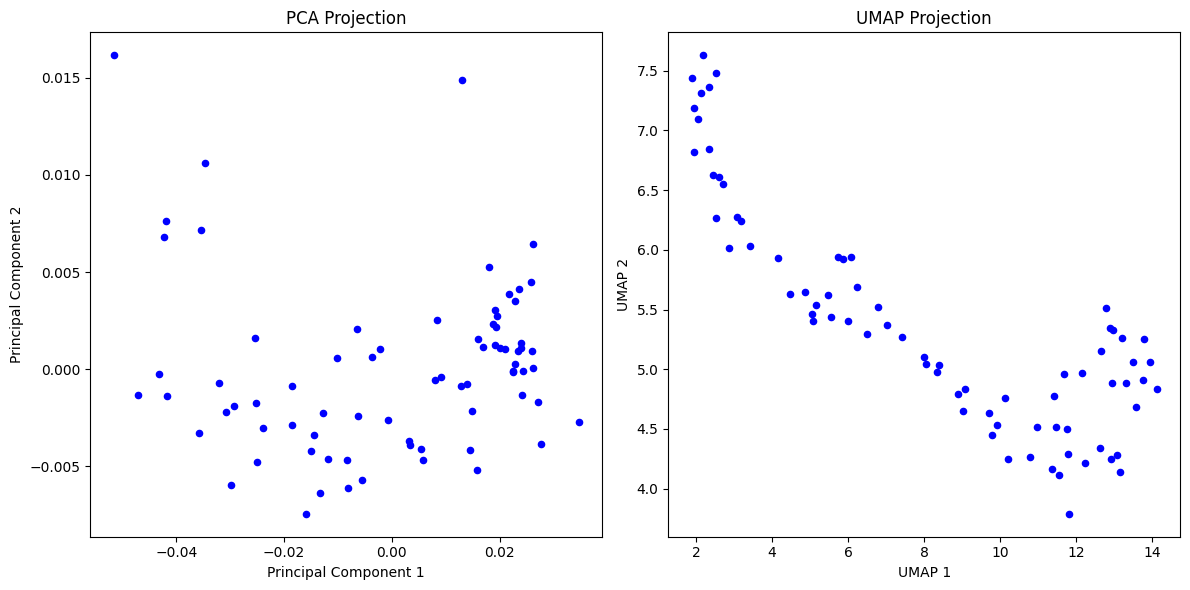

In [145]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import numpy as np

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#embeddings_scaled = scaler.fit_transform(embeddings)
embeddings_scaled = embeddings

pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(embeddings_scaled)

umap_model = umap.UMAP(n_components=2, random_state=42)
umap_embeddings = umap_model.fit_transform(embeddings_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#axes[0].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c=kmeans_labels, cmap='viridis', s=20)
axes[0].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], s=20, color='b')
axes[0].set_title("PCA Projection")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

#axes[1].scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=kmeans_labels, cmap='viridis', s=20)
axes[1].scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], s=20, color='b')
axes[1].set_title("UMAP Projection")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()


Now lets implement some clustering methods 
These will be the same across all GNN models 

1. K-Means clustering

In [146]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
n_clusters = 3

def kmeans_clustering(embeddings, n_clusters=3):
    # Convert embeddings to numpy array
    embeddings = np.array(embeddings)
    
    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    
    # Fit the model
    kmeans.fit(embeddings)
    
    # Get cluster labels
    labels = kmeans.labels_
    
    return labels


kmeans_labels = kmeans_clustering(embeddings, n_clusters)
print(kmeans_labels)


[2 1 1 1 0 1 1 1 0 2 2 1 0 1 1 2 0 0 0 1 2 2 0 1 0 1 1 0 0 1 1 0 2 2 0 1 0
 1 1 2 0 0 1 1 1 1 1 1 0 2 2 2 2 1 2 1 1 2 0 0 1 1 1 0 2 1 1 1 2 1 1 0 1 1
 0]


In [28]:
def kmeans_clustering(embeddings, n_clusters=2):
    # Convert embeddings to numpy array and scale them
    embeddings = np.array(embeddings)
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)
    
    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
    
    # Fit the model and get cluster labels
    labels = kmeans.fit_predict(embeddings_scaled)
    
    return labels
kmeans_labels = kmeans_clustering(avg_embs, n_clusters=3)
print(kmeans_labels)

[2 1 1 1 0 0 1 1 0 2 2 1 0 0 1 2 0 0 0 1 2 2 0 1 0 1 1 0 0 1 1 0 2 2 0 1 0
 1 1 2 0 0 1 1 1 1 1 1 0 2 2 2 2 1 2 1 1 2 0 0 1 1 1 0 2 1 1 1 2 1 1 0 1 1
 0]


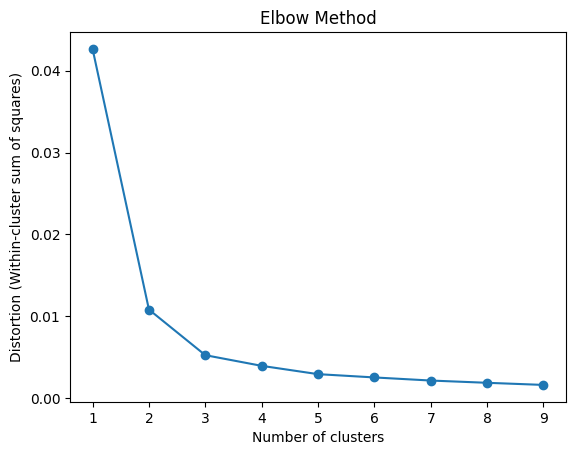

In [147]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow method to determine optimal clusters
distortions = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(embeddings_scaled)
    distortions.append(kmeans.inertia_)

plt.plot(range(1, 10), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion (Within-cluster sum of squares)')
plt.title('Elbow Method')
plt.show()


In [148]:
import re

patient_ids = list(patient_graphs.keys())
patient_numbers = [int(re.search(r'\d+', pid).group()) for pid in patient_ids]

# Create cluster dictionary
cluster_dict = {}

for idx, cluster in enumerate(kmeans_labels):
    patient_num = patient_numbers[idx] 
    #print((patient_num)) 
    if cluster not in cluster_dict:
        cluster_dict[cluster] = []
    cluster_dict[cluster].append(patient_num)

for cluster, patients in sorted(cluster_dict.items()):
    print(f"Cluster {cluster}:")
    for patient_num in sorted(patients):
        print(patient_num) 
    print()

Cluster 0:
19
26
30
32
34
36
37
41
48
53
55
62
66
69
72
77
78
81
82
85
96

Cluster 1:
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
20
21
22
23
24
25
43
45
47
49
60
63
70
75
86
89
91
92
93
94

Cluster 2:
1
29
33
38
39
50
54
61
64
73
74
76
79
80
83
87
88



In [23]:
import re

#patient_ids = list(patient_graphs.keys())
patient_numbers = filtered_patient_numbers

# Create cluster dictionary
cluster_dict = {}

for idx, cluster in enumerate(kmeans_labels):
    patient_num = patient_numbers[idx] 
    #print((patient_num)) 
    if cluster not in cluster_dict:
        cluster_dict[cluster] = []
    cluster_dict[cluster].append(patient_num)

for cluster, patients in sorted(cluster_dict.items()):
    print(f"Cluster {cluster}:")
    for patient_num in sorted(patients):
        print(patient_num) 
    print()

Cluster 0:
1
29
33
38
39
50
54
61
64
73
74
76
77
79
80
81
83
87
88

Cluster 1:
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
20
21
23
24
25
43
45
47
49
60
63
70
75
86
89
91
92
93
94

Cluster 2:
19
22
26
30
32
34
36
37
41
48
53
55
62
66
69
72
78
82
85
96



/home/vsayyalasomayajula/Documents/PythonEnvs/gnn/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vsayyalasomayajula/Documents/PythonEnvs/gnn/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


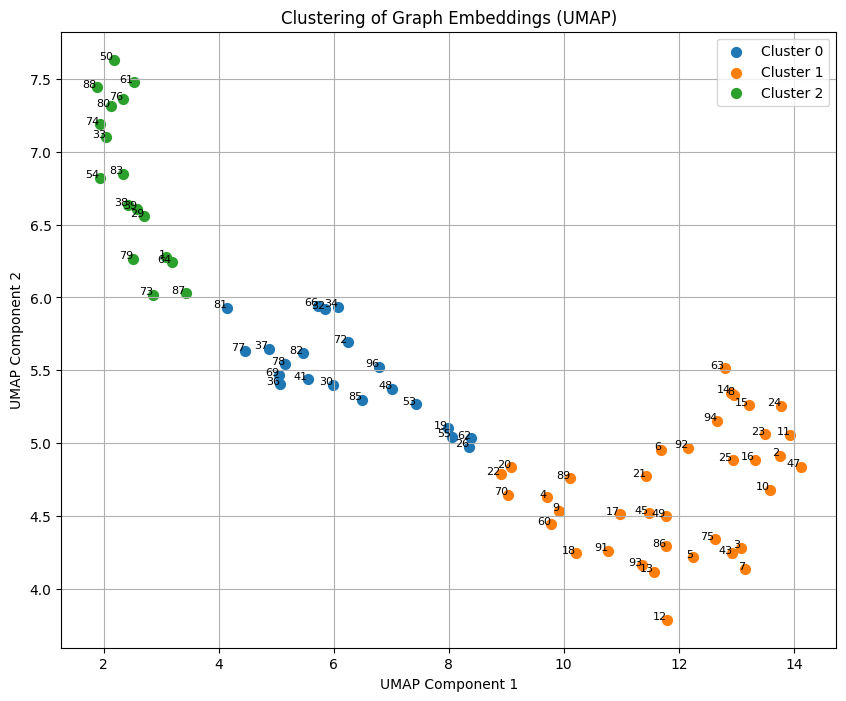

In [149]:
import matplotlib.pyplot as plt
import umap
import numpy as np
import re

def plot_clusters_umap(embeddings, labels, patient_ids, n_clusters=3, annotate=True):
    embeddings = np.array(embeddings)

    # UMAP dimensionality reduction
    reducer = umap.UMAP(n_components=2, random_state=42)
    reduced_embeddings = reducer.fit_transform(embeddings)

    # Plot the clusters
    plt.figure(figsize=(10, 8))

    for cluster in range(n_clusters):
        cluster_indices = np.where(labels == cluster)[0]
        plt.scatter(
            reduced_embeddings[cluster_indices, 0], 
            reduced_embeddings[cluster_indices, 1], 
            label=f'Cluster {cluster}', 
            s=50
        )

        if annotate:
            for i in cluster_indices:
                patient_number = patient_ids[i]
                plt.text(
                    reduced_embeddings[i, 0], 
                    reduced_embeddings[i, 1], 
                    patient_number, 
                    fontsize=8, 
                    ha='right'
                )

    plt.title('Clustering of Graph Embeddings (UMAP)')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_clusters_umap(embeddings, kmeans_labels, filtered_patient_numbers, n_clusters)

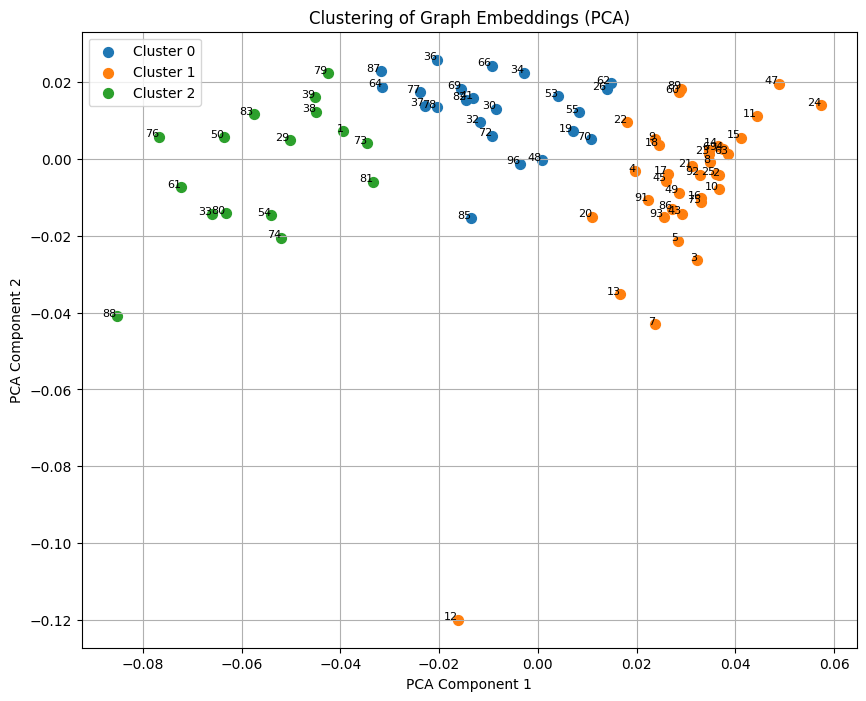

In [131]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import re

def plot_clusters_pca(embeddings, labels, patient_ids, n_clusters=3, annotate=True):
    embeddings = np.array(embeddings)

    # PCA dimensionality reduction
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)

    # Plot the clusters
    plt.figure(figsize=(10, 8))

    for cluster in range(n_clusters):
        cluster_indices = np.where(labels == cluster)[0]
        plt.scatter(
            reduced_embeddings[cluster_indices, 0], 
            reduced_embeddings[cluster_indices, 1], 
            label=f'Cluster {cluster}', 
            s=50
        )

        if annotate:
            for i in cluster_indices:
                patient_number = patient_ids[i]
                plt.text(
                    reduced_embeddings[i, 0], 
                    reduced_embeddings[i, 1], 
                    patient_number, 
                    fontsize=8, 
                    ha='right'
                )

    plt.title('Clustering of Graph Embeddings (PCA)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_clusters_pca(filtered_embeddings, kmeans_labels, filtered_patient_numbers, n_clusters)


Gaussian Mixture Model (GMM)

In [177]:
from sklearn.mixture import GaussianMixture

def gmm_clustering(embeddings, n_components=5):
    # Convert embeddings to numpy array
    embeddings = np.array(embeddings)
    
    # Initialize GMM
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    
    # Fit the model
    gmm.fit(embeddings)
    
    # Get cluster labels
    labels = gmm.predict(embeddings)
    
    return labels

# Example usage
gmm_labels = gmm_clustering(embeddings, n_components=5)
print(gmm_labels)


[3 4 1 1 2 4 1 1 2 3 2 1 0 4 1 3 2 0 0 1 3 2 4 1 4 1 1 4 0 1 1 2 4 3 4 1 4
 1 1 2 4 2 1 1 1 1 1 4 4 2 2 2 3 1 2 4 1 0 2 0 1 1 1 4 2 4 1 1 3 1 1 2 1 1
 4]


In [28]:
patient_ids = list(patient_graphs.keys())

# Create a dictionary to hold cluster IDs and corresponding patient IDs
cluster_dict = {}
for idx, cluster in enumerate(gmm_labels):  # Use gmm_labels here
    patient_id = patient_ids[idx]
    if cluster not in cluster_dict:
        cluster_dict[cluster] = []
    cluster_dict[cluster].append(patient_id)

# Print the samples in each cluster
for cluster, patients in sorted(cluster_dict.items()):
    print(f"Cluster {cluster}:")
    sorted_patients = sorted(patients, key=lambda x: int(re.search(r'\d+', x).group()))  # Sort patients numerically
    
    for patient in sorted_patients:
        patient_number = re.search(r'\d+', patient).group()  # Extract the numeric part
        print(f"  Sample {patient_number}")
    print()

Cluster 0:
  Sample 1
  Sample 32
  Sample 33
  Sample 34
  Sample 36
  Sample 37
  Sample 38
  Sample 39
  Sample 41
  Sample 54
  Sample 64
  Sample 66
  Sample 69
  Sample 72
  Sample 73
  Sample 77
  Sample 78
  Sample 80
  Sample 81
  Sample 82
  Sample 87
  Sample 88

Cluster 1:
  Sample 2
  Sample 8
  Sample 10
  Sample 12
  Sample 14
  Sample 16
  Sample 17
  Sample 18
  Sample 20
  Sample 23
  Sample 45
  Sample 47
  Sample 49
  Sample 86
  Sample 91
  Sample 92
  Sample 93

Cluster 2:
  Sample 29
  Sample 50
  Sample 61
  Sample 76
  Sample 79
  Sample 83

Cluster 3:
  Sample 4
  Sample 9
  Sample 19
  Sample 22
  Sample 26
  Sample 30
  Sample 48
  Sample 53
  Sample 55
  Sample 60
  Sample 62
  Sample 70
  Sample 74
  Sample 85
  Sample 89
  Sample 96

Cluster 4:
  Sample 3
  Sample 5
  Sample 6
  Sample 7
  Sample 11
  Sample 13
  Sample 15
  Sample 21
  Sample 24
  Sample 25
  Sample 43
  Sample 63
  Sample 75
  Sample 94



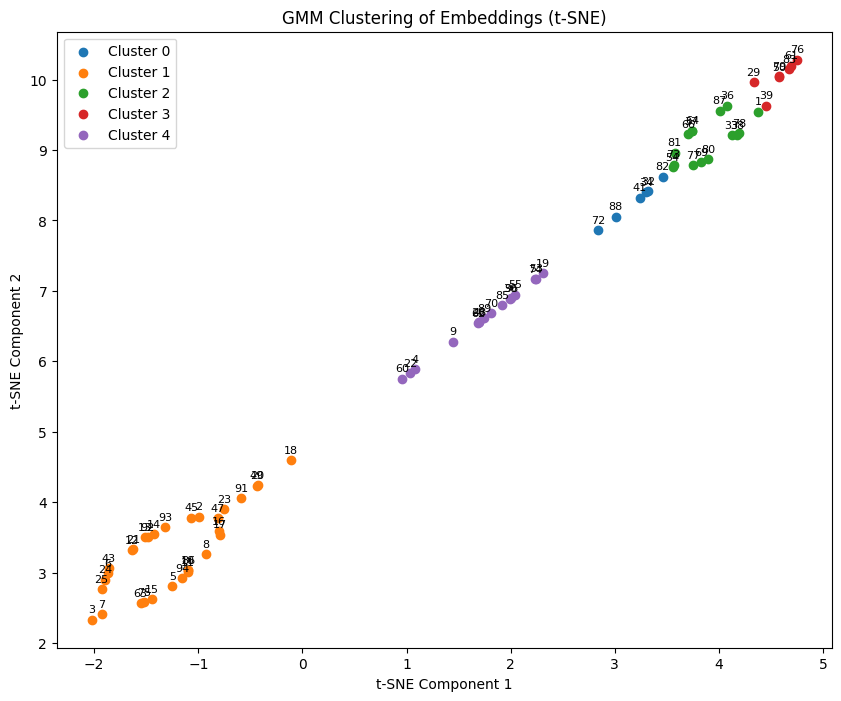

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import re  # To extract the numeric part of patient ID

def plot_gmm_clusters_tsne(embeddings, labels, patient_ids):
    embeddings = np.array(embeddings)

    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))

    unique_labels = set(labels)
    for label in unique_labels:
        cluster_indices = np.where(labels == label)[0]
        plt.scatter(
            reduced_embeddings[cluster_indices, 0], 
            reduced_embeddings[cluster_indices, 1], 
            label=f'Cluster {label}'
        )

        # Add annotations with only numeric part of the patient ID
        for i in cluster_indices:
            # Extract the numeric part of the patient ID using regex
            patient_number = re.search(r'\d+', patient_ids[i]).group()
            plt.annotate(patient_number, 
                         (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), 
                         textcoords="offset points", 
                         xytext=(0, 5), 
                         ha='center', fontsize=8)

    plt.title('GMM Clustering of Embeddings (t-SNE)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.show()

# Example usage
plot_gmm_clusters_tsne(embeddings, gmm_labels, patient_ids)


Spectral Clustering

In [31]:
from sklearn.cluster import SpectralClustering

n_clusters=3

def spectral_clustering(embeddings, n_clusters):
    # Convert embeddings to numpy array
    embeddings = np.array(embeddings)
    
    # Initialize Spectral Clustering
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
    
    # Fit the model
    labels = spectral.fit_predict(embeddings)
    
    return labels

# Example usage
spectral_labels = spectral_clustering(embeddings, n_clusters)
print(spectral_labels)


[0 2 1 1 0 2 1 1 0 0 0 1 0 2 1 0 0 0 0 1 0 0 2 1 2 1 1 2 0 1 1 0 2 0 2 1 2
 1 1 0 2 0 1 1 1 1 1 2 2 0 0 0 0 1 0 2 1 2 0 0 1 1 1 2 0 2 1 1 0 1 1 0 1 1
 2]


In [36]:
patient_ids = list(patient_graphs.keys())

# Create a dictionary to hold cluster IDs and corresponding patient IDs
cluster_dict = {}
for idx, cluster in enumerate(spectral_labels): 
    patient_id = patient_ids[idx]
    if cluster not in cluster_dict:
        cluster_dict[cluster] = []
    cluster_dict[cluster].append(patient_id)

# Print the samples in each cluster
for cluster, patients in sorted(cluster_dict.items()):
    print(f"Cluster {cluster}:")
    sorted_patients = sorted(patients, key=lambda x: int(re.search(r'\d+', x).group()))  # Sort patients numerically
    
    for patient in sorted_patients:
        patient_number = re.search(r'\d+', patient).group()  # Extract the numeric part
        print(f"  Sample {patient_number}")
    print()

Cluster 0:
  Sample 1
  Sample 29
  Sample 32
  Sample 33
  Sample 34
  Sample 36
  Sample 37
  Sample 38
  Sample 39
  Sample 41
  Sample 50
  Sample 54
  Sample 61
  Sample 64
  Sample 66
  Sample 69
  Sample 72
  Sample 73
  Sample 76
  Sample 77
  Sample 78
  Sample 79
  Sample 80
  Sample 81
  Sample 82
  Sample 83
  Sample 87

Cluster 1:
  Sample 2
  Sample 3
  Sample 5
  Sample 6
  Sample 7
  Sample 8
  Sample 10
  Sample 11
  Sample 12
  Sample 13
  Sample 14
  Sample 15
  Sample 16
  Sample 17
  Sample 18
  Sample 20
  Sample 21
  Sample 23
  Sample 24
  Sample 25
  Sample 43
  Sample 45
  Sample 47
  Sample 49
  Sample 63
  Sample 75
  Sample 86
  Sample 91
  Sample 92
  Sample 93
  Sample 94

Cluster 2:
  Sample 4
  Sample 9
  Sample 19
  Sample 22
  Sample 26
  Sample 30
  Sample 48
  Sample 53
  Sample 55
  Sample 60
  Sample 62
  Sample 70
  Sample 74
  Sample 85
  Sample 88
  Sample 89
  Sample 96



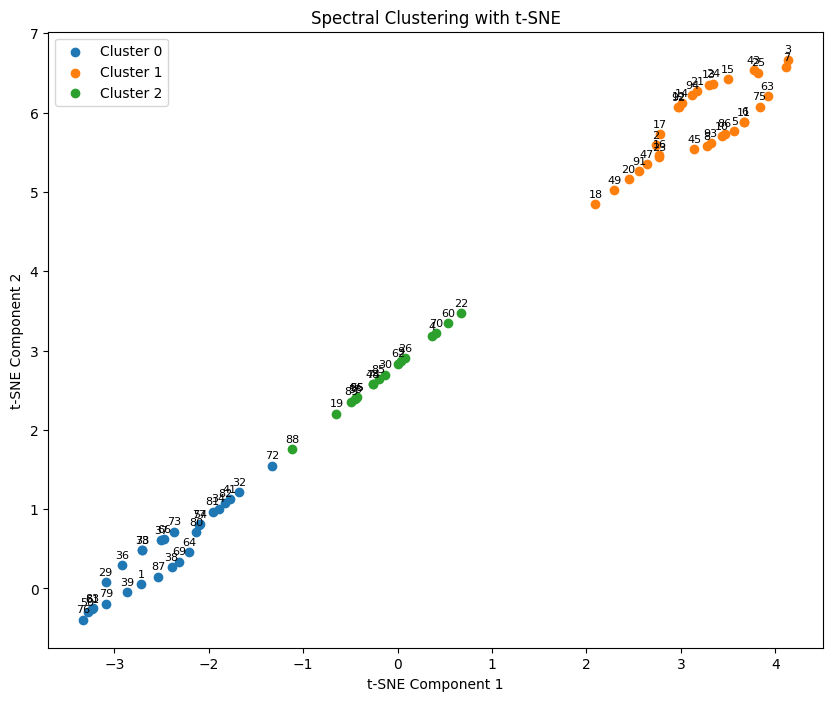

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import re  # To extract the numeric part of patient ID

def plot_spectral_clustering_tsne(embeddings, labels, patient_ids):
    # Reduce dimensionality to 2D using t-SNE
    embeddings = np.array(embeddings)
    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    # Plot each cluster
    plt.figure(figsize=(10, 8))
    unique_labels = set(labels)
    for label in unique_labels:
        cluster_indices = np.where(labels == label)[0]
        plt.scatter(
            reduced_embeddings[cluster_indices, 0], 
            reduced_embeddings[cluster_indices, 1], 
            label=f'Cluster {label}'
        )

        # Add annotations with only numeric part of the patient ID
        for i in cluster_indices:
            # Extract the numeric part of the patient ID using regex
            patient_number = re.search(r'\d+', patient_ids[i]).group()
            plt.annotate(patient_number, 
                         (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), 
                         textcoords="offset points", 
                         xytext=(0, 5), 
                         ha='center', fontsize=8)

    plt.title('Spectral Clustering with t-SNE')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.show()

plot_spectral_clustering_tsne(embeddings, spectral_labels, patient_ids)


Evaluate Clusters

Read true labels

In [26]:
import pandas as pd
import re

patient_ids = list(patient_graphs.keys())
patient_numbers = [int(match.group()) for pid in patient_ids if (match := re.search(r'\d+', pid))]

print(patient_numbers)



[39, 22, 15, 45, 37, 89, 5, 91, 81, 83, 1, 8, 41, 70, 7, 61, 69, 34, 82, 93, 76, 87, 30, 21, 62, 25, 94, 26, 72, 24, 49, 66, 74, 79, 55, 43, 53, 23, 92, 33, 96, 78, 2, 75, 16, 12, 86, 60, 19, 80, 73, 38, 29, 11, 64, 4, 47, 88, 36, 32, 63, 17, 20, 85, 54, 9, 13, 10, 50, 3, 6, 77, 14, 18, 48]


In [27]:
import pandas as pd

df = pd.read_csv("/home/vsayyalasomayajula/Documents/Proteomics/PlasmaAAA/Proteomics sample labels.csv")

df["Patient_Num"] = df["Sample_index"].str.extract(r'(\d+)').astype(int)

valid_patients = set(patient_numbers) 

true_labels_dict = {
    row["Patient_Num"]: row["TrueLabel"]
    for _, row in df.iterrows()
    if row["Patient_Num"] in valid_patients
}

print(true_labels_dict)
print(f"Number of matched patients: {len(true_labels_dict)}")

{1: 0, 2: 1, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 1, 14: 1, 15: 0, 16: 1, 17: 0, 18: 0, 19: 0, 20: 0, 21: 1, 22: 1, 23: 1, 24: 0, 25: 0, 26: 1, 29: 0, 30: 1, 32: 0, 33: 0, 34: 0, 36: 0, 37: 0, 38: 0, 39: 0, 41: 0, 43: 0, 45: 0, 47: 0, 48: 0, 49: 1, 50: 0, 53: 1, 54: 0, 55: 0, 60: 2, 61: 2, 62: 2, 63: 2, 64: 2, 66: 2, 69: 2, 70: 2, 72: 2, 73: 2, 74: 2, 75: 2, 76: 0, 77: 0, 78: 0, 79: 0, 80: 0, 81: 0, 82: 0, 83: 1, 85: 1, 86: 1, 87: 0, 88: 0, 89: 0, 91: 1, 92: 1, 93: 1, 94: 1, 96: 1}
Number of matched patients: 75


In [28]:
import re

patient_numbers = [
    int(re.search(r'\d+', pid).group()) 
    for pid in patient_graphs.keys()
]

patient_to_cluster = dict(zip(patient_numbers, kmeans_labels))

print(patient_to_cluster)

{39: 0, 22: 2, 15: 1, 45: 1, 37: 2, 89: 1, 5: 1, 91: 1, 81: 0, 83: 0, 1: 0, 8: 1, 41: 2, 70: 1, 7: 1, 61: 0, 69: 2, 34: 2, 82: 2, 93: 1, 76: 0, 87: 0, 30: 2, 21: 1, 62: 2, 25: 1, 94: 1, 26: 2, 72: 2, 24: 1, 49: 1, 66: 2, 74: 0, 79: 0, 55: 2, 43: 1, 53: 2, 23: 1, 92: 1, 33: 0, 96: 2, 78: 2, 2: 1, 75: 1, 16: 1, 12: 1, 86: 1, 60: 1, 19: 2, 80: 0, 73: 0, 38: 0, 29: 0, 11: 1, 64: 0, 4: 1, 47: 1, 88: 0, 36: 2, 32: 2, 63: 1, 17: 1, 20: 1, 85: 2, 54: 0, 9: 1, 13: 1, 10: 1, 50: 0, 3: 1, 6: 1, 77: 0, 14: 1, 18: 1, 48: 2}


Cluster performance measures

In [29]:
true_labels_dict = true_labels_dict  # Replace with your actual true labels dictionary
cluster_labels_dict = patient_to_cluster  # Replace with your actual cluster labels dictionary

# Extract the labels and patient ids from the dictionaries
patient_ids = list(true_labels_dict.keys())
true_labels = np.array([true_labels_dict[pid] for pid in patient_ids])
cluster_labels = np.array([cluster_labels_dict[pid] for pid in patient_ids])

Silhoutte index

In [30]:
from sklearn.metrics import silhouette_samples
from sklearn.preprocessing import StandardScaler
import numpy as np

embeddings = filtered_embeddings 

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

cluster_labels = kmeans_labels

silhouette_vals = silhouette_samples(embeddings_scaled, cluster_labels)

unique_clusters = np.unique(cluster_labels)

cluster_scores = {}
for cluster in unique_clusters:
    cluster_indices = cluster_labels == cluster

    cluster_silhouette = silhouette_vals[cluster_indices]
    
    cluster_scores[cluster] = np.mean(cluster_silhouette)

for cluster, score in cluster_scores.items():
    print(f"Cluster {cluster}: Silhouette Score = {score:.4f}")


Cluster 0: Silhouette Score = 0.3535
Cluster 1: Silhouette Score = 0.6251
Cluster 2: Silhouette Score = 0.4282


In [31]:
from sklearn.metrics import davies_bouldin_score

dbi_score = davies_bouldin_score(embeddings_scaled, cluster_labels)
print(f"Davies-Bouldin Index: {dbi_score:.4f}")


Davies-Bouldin Index: 0.7569


In [92]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(embeddings, cluster_labels)
print(f"Calinski-Harabasz Index: {ch_score:.4f}")

Calinski-Harabasz Index: 291.6002


37
64
76
77


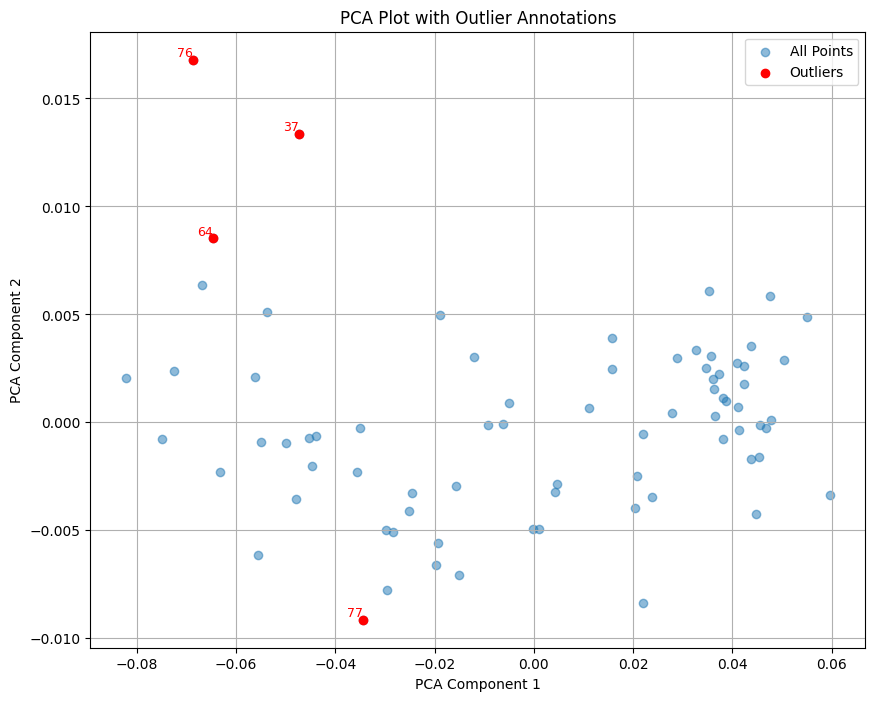

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Perform PCA
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(avg_embs)

#plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1])

#distances_from_centroid = np.linalg.norm(embeddings_pca, axis=1)
#threshold = np.percentile(distances_from_centroid, 95)
#outliers = np.where(distances_from_centroid > threshold)[0]

from scipy.spatial.distance import mahalanobis
import numpy as np

# Compute mean and covariance matrix of PCA embeddings
mean = np.mean(embeddings_pca, axis=0)
cov = np.cov(embeddings_pca, rowvar=False)
inv_covmat = np.linalg.inv(cov)

# Compute Mahalanobis distance for each point
mahalanobis_distances = np.array([
    mahalanobis(x, mean, inv_covmat) for x in embeddings_pca
])

# Use a percentile threshold
threshold = np.percentile(mahalanobis_distances, 95)
outliers = np.where(mahalanobis_distances > threshold)[0]

for idx in outliers:
    print(patient_ids[idx])

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.5, label="All Points")
plt.scatter(embeddings_pca[outliers, 0], embeddings_pca[outliers, 1], color='red', label='Outliers')

# Annotate the outliers
for idx in outliers:
    plt.text(embeddings_pca[idx, 0], embeddings_pca[idx, 1], patient_ids[idx],
             fontsize=9, ha='right', va='bottom', color='red')

plt.title("PCA Plot with Outlier Annotations")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()


Outlier Patient IDs:
37
64
76
77


/home/vsayyalasomayajula/Documents/PythonEnvs/gnn/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vsayyalasomayajula/Documents/PythonEnvs/gnn/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


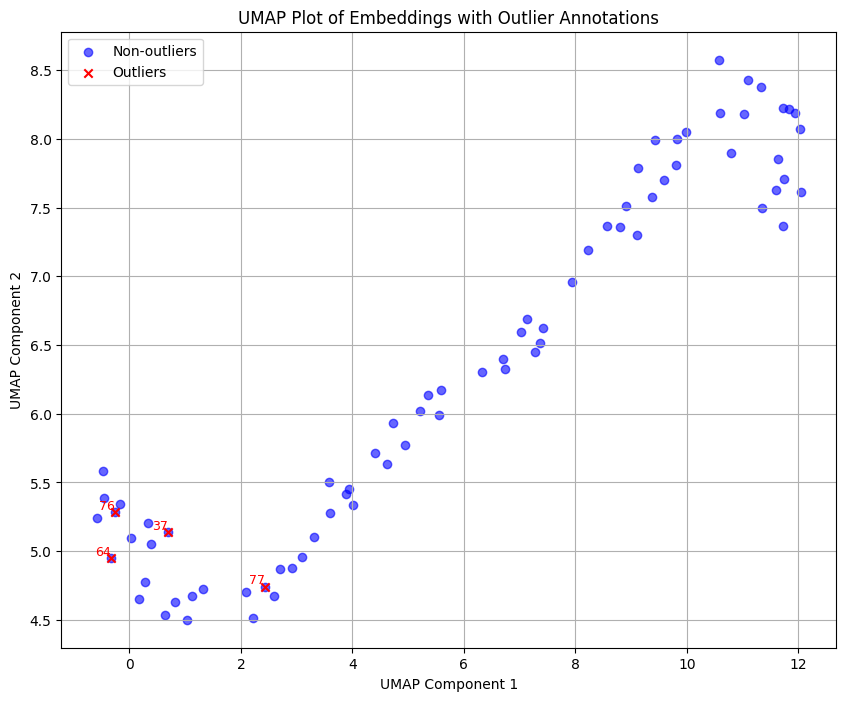

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
from scipy.spatial.distance import mahalanobis

embeddings = np.array(embeddings)

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

# Mahalanobis distance for outlier detection
mean = np.mean(embeddings_pca, axis=0)
cov = np.cov(embeddings_pca, rowvar=False)
inv_covmat = np.linalg.inv(cov)

mahalanobis_distances = np.array([
    mahalanobis(x, mean, inv_covmat) for x in embeddings_pca
])

threshold = np.percentile(mahalanobis_distances, 95)
outliers = np.where(mahalanobis_distances > threshold)[0]

# Print outlier IDs
print("Outlier Patient IDs:")
for idx in outliers:
    print(patient_ids[idx])  # Assumes patient_ids is aligned with embeddings

# UMAP projection
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_umap = reducer.fit_transform(embeddings)

# Plot UMAP with annotations
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_umap[:, 0], embeddings_umap[:, 1], c='blue', label='Non-outliers', alpha=0.6)
plt.scatter(embeddings_umap[outliers, 0], embeddings_umap[outliers, 1], c='red', label='Outliers', marker='x')

# Annotate the outliers
for idx in outliers:
    plt.text(embeddings_umap[idx, 0], embeddings_umap[idx, 1], patient_ids[idx],
             fontsize=9, ha='right', va='bottom', color='red')

plt.title("UMAP Plot of Embeddings with Outlier Annotations")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend()
plt.grid(True)
plt.show()

In [311]:
from scipy.spatial.distance import mahalanobis
import numpy as np

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

mean = np.mean(embeddings_pca, axis=0)
cov = np.cov(embeddings_pca, rowvar=False)
inv_covmat = np.linalg.inv(cov)

mahalanobis_distances = np.array([
    mahalanobis(x, mean, inv_covmat) for x in embeddings_pca
])

threshold = np.percentile(mahalanobis_distances, 95)
outliers = np.where(mahalanobis_distances > threshold)[0]

print("Outlier Patient IDs:")
for idx in outliers:
    print(patient_ids[idx])


Outlier Patient IDs:
Patient_3
Patient_7
Patient_32
Patient_66
Patient_87


In [312]:
from sklearn.ensemble import IsolationForest

pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_preds = iso_forest.fit_predict(embeddings_pca)

outliers = np.where(outlier_preds == -1)[0]
for idx in outliers:
    print(patient_ids[idx])

Patient_7
Patient_32
Patient_66
Patient_67
Patient_87


TRAINING a Classifier based on asymmetric focal loss (unified focal loss)

Unified focal loss

In [31]:
class AsymmetricUnifiedFocalLoss(nn.Module):
    def __init__(self, delta=0.7, gamma=0.5, lambda_=0.5):
        super().__init__()
        self.delta = delta
        self.gamma = gamma
        self.lambda_ = lambda_

    def forward(self, inputs, targets):
        probs = torch.sigmoid(inputs)
        
        # --- (A) Asymmetric Modified Focal Loss (L_maF) ---
        # Rare class (r): No gamma suppression
        rare_mask = (targets == 1)
        bce_rare = -torch.log(probs[rare_mask] + 1e-8)
        L_rare = (self.delta / rare_mask.sum()) * bce_rare.sum() if rare_mask.any() else 0.0

        # Background: Apply gamma suppression
        bg_mask = (targets == 0)
        pt_bg = 1 - probs[bg_mask]
        bce_bg = -torch.log(pt_bg + 1e-8)
        L_bg = ((1 - self.delta) / bg_mask.sum()) * ((1 - pt_bg).pow(self.gamma) * bce_bg).sum() if bg_mask.any() else 0.0

        L_maF = L_rare + L_bg

        # --- (B) Asymmetric Modified Focal Tversky Loss (L_maFT) ---
        TP = (targets * probs).sum()
        FP = ((1 - targets) * probs).sum()
        FN = (targets * (1 - probs)).sum()
        mTI = TP / (TP + self.delta * FN + (1 - self.delta) * FP + 1e-8)

        # Rare class: Enhanced (gamma applied)
        # Background: No gamma (standard term)
        L_maFT = (1 - mTI) + (1 - mTI).pow(1 - self.gamma)

        # --- Combined Loss ---
        return self.lambda_ * L_maF + (1 - self.lambda_) * L_maFT

In [34]:
import torch
import torch.nn.functional as F

import torch
import torch.nn.functional as F

def asymmetric_focal_loss(delta=0.7, gamma=2.):
    """Asymmetric Focal Loss for Imbalanced datasets.
    
    Parameters
    ----------
    delta : float, optional
        Controls the weight given to false positives and false negatives, by default 0.7.
    gamma : float, optional
        Focal parameter controls the degree of down-weighting of easy examples, by default 2.0.
    """
    def loss_function(y_true, y_pred):
        # Ensure values are between epsilon and 1 - epsilon to avoid division by zero
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1. - epsilon)

        # Calculate cross-entropy
        cross_entropy = -y_true * torch.log(y_pred)

        # For the background class, we suppress easy examples
        back_ce = (1 - y_pred) ** gamma * cross_entropy
        back_ce = (1 - delta) * back_ce

        # For the foreground class (positive class), enhance the loss
        fore_ce = y_pred * cross_entropy
        fore_ce = delta * fore_ce

        # Combine both background and foreground class losses
        loss = torch.mean(back_ce + fore_ce)

        return loss

    return loss_function


def asymmetric_focal_tversky_loss(delta=0.7, gamma=0.75):
    """This is the implementation for binary classification with tabular data.
    
    Parameters
    ----------
    delta : float, optional
        controls weight given to false positive and false negatives, by default 0.7
    gamma : float, optional
        focal parameter controls degree of down-weighting of easy examples, by default 0.75
    """
    def loss_function(y_true, y_pred):
        # Clip values to prevent division by zero error
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1. - epsilon)

        # Calculate true positives (tp), false negatives (fn) and false positives (fp)     
        tp = torch.sum(y_true * y_pred)  # True positives: where both y_true and y_pred are 1
        fn = torch.sum(y_true * (1 - y_pred))  # False negatives: where y_true is 1, y_pred is 0
        fp = torch.sum((1 - y_true) * y_pred)  # False positives: where y_true is 0, y_pred is 1
        
        # Calculate Tversky index for the foreground (positive class)
        dice_class = (tp + epsilon) / (tp + delta * fn + (1 - delta) * fp + epsilon)

        # Focal loss for foreground (positive class) and background (negative class)
        back_dice = (1 - dice_class)  # Background class loss
        fore_dice = (1 - dice_class) * torch.pow(1 - dice_class, -gamma)  # Foreground class loss

        # Combine both losses
        loss = torch.mean(back_dice + fore_dice)
        return loss

    return loss_function


def asym_unified_focal_loss(weight=0.5, delta=0.6, gamma=0.5):
    """The Unified Focal loss is a new compound loss function that unifies Dice-based and cross entropy-based loss functions into a single framework.
    Parameters
    ----------
    weight : float, optional
        represents lambda parameter and controls weight given to asymmetric Focal Tversky loss and asymmetric Focal loss, by default 0.5
    delta : float, optional
        controls weight given to each class, by default 0.6
    gamma : float, optional
        focal parameter controls the degree of background suppression and foreground enhancement, by default 0.5
    """
    def loss_function(y_true,y_pred):
      asymmetric_ftl = asymmetric_focal_tversky_loss(delta=delta, gamma=gamma)(y_true,y_pred)
      asymmetric_fl = asymmetric_focal_loss(delta=delta, gamma=gamma)(y_true,y_pred)
      if weight is not None:
        return (weight * asymmetric_ftl) + ((1-weight) * asymmetric_fl)  
      else:
        return asymmetric_ftl + asymmetric_fl

    return loss_function

Classifier

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim=128, hidden_dim1=64, hidden_dim2 = 32):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim2, 1)  
        )

    def forward(self, x):
        logits = self.layers(x)  
        return torch.sigmoid(logits)

model = BinaryClassifier().to(device)
criterion = asym_unified_focal_loss(delta=0.5, gamma=2.5, weight=0.0)  
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)

Data prep

Create labels array

In [38]:
print(patient_ids)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 29, 30, 32, 33, 34, 36, 37, 38, 39, 41, 43, 45, 47, 48, 49, 50, 53, 54, 55, 60, 61, 62, 63, 64, 66, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 91, 92, 93, 94, 96]


In [40]:
import pandas as pd
import numpy as np

patient_ids = patient_ids

df = df = pd.read_csv('/home/vsayyalasomayajula/Documents/Proteomics/PlasmaAAA/Proteomics sample labels.csv')

patient_numbers = [int(pid.split(' ')[1].split('_')[0]) for pid in patient_ids]

labels = []
for pid_number in patient_numbers:

    matching_row = df[df['Sample_index'] == f'Sample.{pid_number}']
    if not matching_row.empty:
        label = matching_row['Label'].values[0]

        labels.append(1 if label == 'Control' else 0)
    else:
        labels.append(0) 
labels = np.array(labels)

print(labels)


[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0]


In [43]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0])

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

# - embeddings: numpy array of shape (75, 128)
# - labels: numpy array of shape (75,) with binary labels (0 or 1)
embeddings = avg_embs
labels = labels

X_train, X_val, y_train, y_val = train_test_split(embeddings, labels, test_size=0.2, stratify=labels)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)

# Optional: Set device for GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move tensors to the correct device if needed
X_train_tensor, y_train_tensor = X_train_tensor.to(device), y_train_tensor.to(device)
X_val_tensor, y_val_tensor = X_val_tensor.to(device), y_val_tensor.to(device)

/tmp/ipykernel_1136135/3367964704.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  X_train_tensor = torch.FloatTensor(X_train)


In [45]:
print(len(embeddings)) 
print(len(labels))

75
75


In [56]:
print(type(embeddings))


<class 'list'>


Training loop

In [57]:
def train_model(model, train_loader, val_loader, epochs=100):
    best_val_loss = float('inf')
    patience = 0
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze() 
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X).squeeze()
                val_loss += criterion(outputs, batch_y).item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == batch_y).sum().item()
        
        # Metrics
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_acc = correct / len(val_loader.dataset)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            patience = 0 
        else:
            patience += 1
            if patience >= 10:
                print("Early stopping!")
                break
        
        # Update learning rate if using scheduler
        scheduler.step()
    
    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    return model

trained_model = train_model(model, train_loader, val_loader, epochs=100)

Epoch 1/100 | Train Loss: 3.5309 | Val Loss: 3.6612 | Val Acc: 0.1333
Epoch 2/100 | Train Loss: 3.5304 | Val Loss: 3.6546 | Val Acc: 0.1333
Epoch 3/100 | Train Loss: 3.5364 | Val Loss: 3.6480 | Val Acc: 0.1333
Epoch 4/100 | Train Loss: 3.4184 | Val Loss: 3.6413 | Val Acc: 0.1333
Epoch 5/100 | Train Loss: 3.5065 | Val Loss: 3.6345 | Val Acc: 0.1333
Epoch 6/100 | Train Loss: 3.5564 | Val Loss: 3.6277 | Val Acc: 0.1333
Epoch 7/100 | Train Loss: 3.4489 | Val Loss: 3.6209 | Val Acc: 0.1333
Epoch 8/100 | Train Loss: 3.5044 | Val Loss: 3.6141 | Val Acc: 0.1333
Epoch 9/100 | Train Loss: 3.4440 | Val Loss: 3.6075 | Val Acc: 0.1333
Epoch 10/100 | Train Loss: 3.4693 | Val Loss: 3.6007 | Val Acc: 0.1333
Epoch 11/100 | Train Loss: 3.5005 | Val Loss: 3.5973 | Val Acc: 0.1333
Epoch 12/100 | Train Loss: 3.4322 | Val Loss: 3.5939 | Val Acc: 0.1333
Epoch 13/100 | Train Loss: 3.4332 | Val Loss: 3.5904 | Val Acc: 0.1333
Epoch 14/100 | Train Loss: 3.4860 | Val Loss: 3.5869 | Val Acc: 0.1333
Epoch 15/100 | 

/tmp/ipykernel_2906508/576942091.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


Test with XG boost

In [59]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torch
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming your PyTorch tensors are X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor

# Convert PyTorch tensors to NumPy arrays for XGBoost
X_train_np = X_train_tensor.cpu().numpy()  # Move to CPU and convert to NumPy
y_train_np = y_train_tensor.cpu().numpy()
X_val_np = X_val_tensor.cpu().numpy()
y_val_np = y_val_tensor.cpu().numpy()

# Initialize XGBoost model
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# Train the model
model.fit(X_train_np, y_train_np)

# Predict on validation set
y_pred = model.predict(X_val_np)
y_pred_proba = model.predict_proba(X_val_np)[:, 1]


# Evaluate the model
print("Accuracy:", accuracy_score(y_val_np, y_pred))
print("AUC:", roc_auc_score(y_val_np, y_pred_proba))

# Precision, Recall, F1 Score
print("Precision:", precision_score(y_val_np, y_pred))
print("Recall:", recall_score(y_val_np, y_pred))
print("F1 Score:", f1_score(y_val_np, y_pred))


Accuracy: 0.8
AUC: 0.34615384615384615
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import seaborn as sns

# Plot AUROC Curve
fpr, tpr, _ = roc_curve(y_val_np, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='b', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUROC Curve')
plt.legend(loc='lower right')

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val_np, y_pred_proba)

plt.subplot(1, 3, 2)
plt.plot(recall, precision, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Plot Confusion Matrix
cm = confusion_matrix(y_val_np, y_pred)
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()


Modified loss for XGBoost

In [97]:
import xgboost as xgb
import numpy as np 

################################################################
#                 Cost sensing XGBoost (CSXGBoost)             #
################################################################
def gradient_csxgb(preds: np.ndarray, dtrain: xgb.DMatrix,c0=1.0,c1=1.0):           
    labels = dtrain.get_label()
    preds=1/(1+np.exp(-2*preds))
    preds2=1-preds    
    fy=(1/(c1+c0))*np.log((preds*c1)/(preds2*c0)) 
    eta=0.5*np.log(c0/c1)
    delta=(c1+c0)/2   
    py=1/(1+np.exp((-2*delta*fy)-(2*eta)))
    grad=-2*delta*(labels-py) 
    return grad

def hessian_csxgb(preds: np.ndarray, dtrain: xgb.DMatrix,c0=1,c1=1):      
    preds=1/(1+np.exp(-2*preds))
    preds2=1-preds    
    fy=(1/(c1+c0))*np.log((preds*c1)/(preds2*c0)) 
    eta=0.5*np.log(c0/c1)
    delta=(c1+c0)/2   
    py=1/(1+np.exp((-2*delta*fy)-(2*eta)))
    hess= 4*np.power(delta,2)*py*(1-py)
    return hess
''' CSXGBoost.'''
def cost_sensing_xgb (c0=1.0,c1=1.0):    
    def csxgb(preds: np.ndarray, dtrain: xgb.DMatrix):
        """Xia, Y., Liu, C., & Liu, N. (2017). Cost-sensitive boosted tree for loan evaluation in peer-to-peer lending.
        Electronic Commerce Research and Applications, 24, 30-49. 
        Parameters
        ----------
        c0 : float, default value is 1.0
            denote the cost of incorrectly classifying a negative case (y=0) as a positive case (y=1).
        c1 : float, default value is 1.0
            denote the cost of incorrectly classifying a positive case (y=1) as a negative case (y=0)."""
        grad = gradient_csxgb(preds, dtrain,c0,c1)
        hess = hessian_csxgb(preds, dtrain,c0,c1)
        return grad, hess
    return csxgb


################################################################
# Symmetric  Modified Focal loss with  Cost sensing link       #
################################################################

def gradient_mfcsxgb(preds: np.ndarray, dtrain: xgb.DMatrix,c0=1.0,c1=1.0,gamma1=0.0,alpha=1.0):           
    labels = dtrain.get_label()
    preds=1/(1+np.exp(-2*preds))
    preds2=1-preds    
    fy=(1/(c1+c0))*np.log((preds*c1)/(preds2*c0)) 
    eta=0.5*np.log(c0/c1)
    delta=(c1+c0)/2   
    py=1/(1+np.exp((-2*delta*fy)-(2*eta)))
    eta1=np.power(1-py,gamma1)*(1-np.divide(gamma1*py*np.log(py),1-py))
    eta2=np.power(py,gamma1)*(np.divide(gamma1*(1-py)*np.log(1-py),py)-1)      
    grad=-2*delta*(alpha*labels*(1-py)*eta1+(1-labels)*py*eta2) 
    return grad

def hessian_mfcsxgb(preds: np.ndarray, dtrain: xgb.DMatrix,c0=1,c1=1,gamma1=0.0,alpha=1.0):  
    labels = dtrain.get_label()    
    preds=1/(1+np.exp(-2*preds))
    preds2=1-preds    
    fy=(1/(c1+c0))*np.log((preds*c1)/(preds2*c0)) 
    eta=0.5*np.log(c0/c1)
    delta=(c1+c0)/2   
    py=1/(1+np.exp((-2*delta*fy)-(2*eta)))
    eta1=np.power(1-py,gamma1)*(1-np.divide(gamma1*py*np.log(py),1-py))
    eta2=np.power(py,gamma1)*(np.divide(gamma1*(1-py)*np.log(1-py),py)-1)    
    eta3=np.power(1-py,gamma1)*(np.divide(gamma1*py,1-py)*(np.divide((gamma1-1)*py*np.log(py),1-py)-2)-1)
    eta4=np.power(py,gamma1)*(np.divide(gamma1*(1-py),py)*(np.divide((gamma1-1)*(1-py)*np.log(1-py),py)-2)-1)
    hess_part1=(alpha*labels*(1-py)*eta1)+((1-labels)*py*eta2)
    hess_part2=(alpha*labels*eta3*(1-py)**2)+((1-labels)*eta4*py**2)
    hess= -4*np.power(delta,2)*((1-2*py)*hess_part1+hess_part2)
    return hess
''' Cost-sensitive XGBoost with a modified Focal loss.'''
def modified_focal_loss_csxgb (c0=1.0,c1=1.0,gamma1=0.0,alpha=1.0):    
    def mfcsxgb(preds: np.ndarray, dtrain: xgb.DMatrix):
        """Mushava, J., & Murray, M. (2022). A novel XGBoost extension for credit scoring class-imbalanced data combining a generalized extreme value link and a modified focal loss function.
        Expert Systems with Applications, 202, 117233. 
        Parameters
        ----------
        c0 : float, default value is 1.0
            link function parameter. Denote the cost of incorrectly classifying a negative case (y=0) as a positive case (y=1).
        c1 : float, default value is 1.0
            link function parameter. Denote the cost of incorrectly classifying a positive case (y=1) as a negative case (y=0).
        alpha : float, default value is 1.0.
            Penalty parameter in the loss function control the degree of weight assigned to the misclassifcation of the positive class (y = 1).
        gamma1 : float, default value is 1.0
            focal parameter controls degree of down-weighting of easy to classify cases."""
        grad = gradient_mfcsxgb(preds, dtrain,c0,c1,gamma1,alpha)
        hess = hessian_mfcsxgb(preds, dtrain,c0,c1,gamma1,alpha)
        return grad, hess
    return mfcsxgb

   


####################################################################################
#     Asymmetric Positive class (y=1) Modified Focal loss    with GEV link         #
####################################################################################
def gradient_maf_gev1(preds: np.ndarray, dtrain: xgb.DMatrix,alpha=1.0, gamma1=0.0,tau=-0.25):           
    labels = dtrain.get_label()
    preds=np.exp(-np.power(1 + (tau*preds),-1/tau))
    n1s=-(gamma1*preds*((1-preds)**(gamma1-1))*np.log(preds))+((1-preds)**gamma1)
    n2a=((1-preds)*np.log(1-preds))-preds       
    L1_maF=-((alpha*labels*n1s*(1-preds))+((1-labels)*preds*n2a))/(preds*(1-preds))
    P1_gev=preds*(np.log(1/preds))**(tau+1)
    grad=L1_maF*P1_gev  
    return grad

def hessian_maf_gev1(preds: np.ndarray, dtrain: xgb.DMatrix,alpha=1.0, gamma1=0.0,tau=-0.25):      
    labels = dtrain.get_label()
    preds=np.exp(-np.power(1 + (tau*preds),-1/tau))
    n1s=-(gamma1*preds*((1-preds)**(gamma1-1))*np.log(preds))+((1-preds)**gamma1)
    n2a=((1-preds)*np.log(1-preds))-preds
    n3s=-(2*gamma1*preds*((1-preds)**(gamma1-1)))-((1-preds)**gamma1)+(((gamma1*preds)**2)*((1-preds)**(gamma1-2))*np.log(preds))-(gamma1*preds*preds*((1-preds)**(gamma1-2))*np.log(preds))
    n4a=-(1-preds)      
    L1_maF=-((alpha*labels*n1s*(1-preds))+((1-labels)*preds*n2a))/(preds*(1-preds))
    L2_maF=-((alpha*labels*n3s*(1-preds)**2)+((1-labels)*(preds**2)*n4a))/(preds*(1-preds))**2
    P1_gev=preds*(np.log(1/preds))**(tau+1)
    P2_gev=-preds*((tau+1)*((np.log(1/preds))**-1)-1)*(np.log(1/preds))**(2*(tau+1))
    hess=(L1_maF*P2_gev)+((P1_gev**2)*L2_maF)
    return hess
'''asymmetric modified Focal loss function for positive class  with GEV link.'''
def modified_asy_focal_loss_gev1 (alpha=1.0, gamma1=0.0,tau=-0.25):    
    def mF_gev(preds: np.ndarray, dtrain: xgb.DMatrix):
        """
        Parameters
        ----------
        alpha : float, default value is 1.0.
            Penalty parameter control the degree of weight assigned to the misclassifcation of the positive class (y=1).
        gamma1 : float, default value is 0.0
            The focal parameter controls the degree of down-weighting of easy to classify  positive cases (y=1).
        tau : float, default value is -0.25
            controls the skewness of the standard GEV-distribution based link"""
        grad = gradient_maf_gev1(preds, dtrain,alpha, gamma1,tau)
        hess = hessian_maf_gev1(preds, dtrain,alpha, gamma1,tau)
        return grad, hess
    return mF_gev


####################################################################################
#     Asymmetric Positive class (y=1) Modified Focal loss    with EEL link          #
####################################################################################
def gradient_maf_eel1(preds: np.ndarray, dtrain: xgb.DMatrix,alpha=1.0, gamma1=0.0, lamda=1.0,beta=1.0):           
    labels = dtrain.get_label()
    preds=np.power(1-np.power((1+np.exp(preds)),-lamda),beta)
    psi=1-np.power(preds,1/beta)    
    n1=-(gamma1*preds*((1-preds)**(gamma1-1))*np.log(preds))+((1-preds)**gamma1)
    n2a=((1-preds)*np.log(1-preds))-preds          
    L1_maF=-((alpha*labels*n1*(1-preds))+((1-labels)*preds*n2a))/(preds*(1-preds))
    P1_eel=beta*lamda*psi*(1-np.power(psi,1/lamda))*np.power(1-psi,beta-1) 
    grad=L1_maF*P1_eel  
    return grad

def hessian_maf_eel1(preds: np.ndarray, dtrain: xgb.DMatrix,alpha=1.0, gamma1=0.0, lamda=1.0,beta=1.0):      
    labels = dtrain.get_label()
    preds=np.power(1-np.power((1+np.exp(preds)),-lamda),beta)
    psi=1-np.power(preds,1/beta)
    n1=-(gamma1*preds*((1-preds)**(gamma1-1))*np.log(preds))+((1-preds)**gamma1)
    n2a=((1-preds)*np.log(1-preds))-preds
    n3=-(2*gamma1*preds*((1-preds)**(gamma1-1)))-((1-preds)**gamma1)+(((gamma1*preds)**2)*((1-preds)**(gamma1-2))*np.log(preds))-(gamma1*preds*preds*((1-preds)**(gamma1-2))*np.log(preds))
    n4a=-preds-2*(1-preds)          
    L1_maF=-((alpha*labels*n1*(1-preds))+((1-labels)*preds*n2a))/(preds*(1-preds))
    L2_maF=-((alpha*labels*n3*(1-preds)**2)+((1-labels)*(preds**2)*n4a))/(preds*(1-preds))**2
    P1_eel=beta*lamda*psi*(1-np.power(psi,1/lamda))*np.power(1-psi,beta-1) 
    P2_eel=-beta*lamda*np.power(psi,(beta+(1/lamda)))*(1-np.power(psi,1/lamda))*np.power((1/psi)-1,beta-2)*((1/psi)*(lamda*np.power(psi,-1/lamda)-lamda-1)-beta*lamda*(np.power(psi,-1/lamda)-1)+1)
    hess=(L1_maF*P2_eel)+((P1_eel**2)*L2_maF)
    return hess
''' asymmetric modified Focal loss function for positive class with EEL link.'''
def modified_asy_focal_loss_eel1 (alpha=1.0, gamma1=0.0, lamda=1.0,beta=1.0):    
    def mF_eel(preds: np.ndarray, dtrain: xgb.DMatrix):
        """
        Parameters
        ----------
        alpha : float, default value is 1.0.
            Penalty parameter control the degree of weight assigned to the misclassifcation of the positive class (y = 1).
        gamma1 : float, default value is 0.0
            The focal parameter controls the degree of down-weighting of easy to classify  positive cases (y=1).
        lamda,beta : float, default value is 1.0
            shape parameters for the standard EEL-distribution based link"""
        grad = gradient_mf_eel(preds, dtrain,alpha,lamda, gamma1,beta)
        hess = hessian_mf_eel(preds, dtrain,alpha,lamda, gamma1,beta)
        return grad, hess
    return mF_eel



################################################################
#     Modified Focal Tversky loss  with GEV link             #
################################################################
def gradient_mft_gev(preds: np.ndarray, dtrain: xgb.DMatrix,delta=0.7, gamma2=1.0,tau=-0.25):           
    labels = dtrain.get_label()
    preds=np.exp(-np.power(1 + (tau*preds),-1/tau))
    phi1=preds*(labels+delta-1)-(delta*labels)
    phi2=preds*(delta-1)-(delta*labels)        
    L1_mF=-np.divide((delta*labels)*np.power((phi1/phi2),1/gamma2),gamma2*phi1*phi2)
    P1_gev=preds*(np.log(1/preds))**(tau+1)
    grad=L1_mF*P1_gev  
    return grad

def hessian_mft_gev(preds: np.ndarray, dtrain: xgb.DMatrix,delta=0.7, gamma2=1.0,tau=-0.25):      
    labels = dtrain.get_label()
    preds=np.exp(-np.power(1 + (tau*preds),-1/tau))
    phi1=preds*(labels+delta-1)-(delta*labels)
    phi2=preds*(delta-1)-(delta*labels)            
    L1_mF=-np.divide((delta*labels)*np.power((phi1/phi2),1/gamma2),gamma2*phi1*phi2)
    L2_mF=np.divide((delta*labels)*np.power((phi1/phi2),1/gamma2)*((2*(delta-1)*gamma2*phi1)-(labels*delta*(gamma2-1))),np.power(gamma2*phi1*phi2,2))
    P1_gev=preds*(np.log(1/preds))**(tau+1)
    P2_gev=-preds*((tau+1)*((np.log(1/preds))**-1)-1)*(np.log(1/preds))**(2*(tau+1))
    hess=(L1_mF*P2_gev)+((P1_gev**2)*L2_mF)
    return hess
'''Focal Tversky loss  with GEV link.'''
def modified_focal_tversky_gev (delta=0.7, gamma2=1.0,tau=-0.25):    
    def mFT_gev(preds: np.ndarray, dtrain: xgb.DMatrix):
        """A Novel Focal Tversky loss function with improved Attention U-Net for lesion segmentation
        Link: https://arxiv.org/abs/1810.07842
        Parameters
        ----------
        gamma2 : float and non-zero, default value is 1.0
            The focal parameter controls the degree of enhancement or suppression of the positive  class (y=1).
        delta : float, default value is 0.7
            controls weight given to false positive and false negatives
        tau : float, default value is -0.25
            controls the skewness of the standard GEV-distribution based link"""
        grad = gradient_mft_gev(preds, dtrain,delta, gamma2,tau)
        hess = hessian_mft_gev(preds, dtrain,delta, gamma2,tau)
        return grad, hess
    return mFT_gev


################################################################
#     Modified Focal Tversky loss  with EEL link             #
################################################################
def gradient_mft_eel(preds: np.ndarray, dtrain: xgb.DMatrix,delta=0.7,gamma2=1.0,lamda=1.0, beta=1.0):           
    labels = dtrain.get_label()
    preds=np.power(1-np.power((1+np.exp(preds)),-lamda),beta)
    psi=1-np.power(preds,1/beta)
    phi1=preds*(labels+delta-1)-(delta*labels)
    phi2=preds*(delta-1)-(delta*labels)        
    L1_mF=-np.divide((delta*labels)*np.power((phi1/phi2),1/gamma2),gamma2*phi1*phi2)
    P1_eel=beta*lamda*psi*(1-np.power(psi,1/lamda))*np.power(1-psi,beta-1)
    grad=L1_mF*P1_eel  
    return grad

def hessian_mft_eel(preds: np.ndarray, dtrain: xgb.DMatrix,delta=0.7,gamma2=1.0,lamda=1.0, beta=1.0):      
    labels = dtrain.get_label()
    preds=np.power(1-np.power((1+np.exp(preds)),-lamda),beta)
    psi=1-np.power(preds,1/beta)
    phi1=preds*(labels+delta-1)-(delta*labels)
    phi2=preds*(delta-1)-(delta*labels)            
    L1_mF=-np.divide((delta*labels)*np.power((phi1/phi2),1/gamma2),gamma2*phi1*phi2)
    L2_mF=np.divide((delta*labels)*np.power((phi1/phi2),1/gamma2)*((2*(delta-1)*gamma2*phi1)-(labels*delta*(gamma2-1))),np.power(gamma2*phi1*phi2,2))
    P1_eel=beta*lamda*psi*(1-np.power(psi,1/lamda))*np.power(1-psi,beta-1) 
    P2_eel=-beta*lamda*np.power(psi,(beta+(1/lamda)))*(1-np.power(psi,1/lamda))*np.power((1/psi)-1,beta-2)*((1/psi)*(lamda*np.power(psi,-1/lamda)-lamda-1)-beta*lamda*(np.power(psi,-1/lamda)-1)+1)
    hess=(L1_mF*P2_eel)+((P1_eel**2)*L2_mF)
    return hess
'''Focal Tversky loss  with EEL link.'''
def modified_focal_tversky_eel (delta=0.7,gamma2=1.0,lamda=1.0, beta=1.0):    
    def mFT_eel(preds: np.ndarray, dtrain: xgb.DMatrix):
        """A Novel Focal Tversky loss function with improved Attention U-Net for lesion segmentation
        Link: https://arxiv.org/abs/1810.07842
        Parameters
        ----------
        gamma2 : float and non-zero, default value is 1.0
            The focal parameter controls the degree of enhancement or suppression of the positive  class (y=1).
        delta : float, default value is 0.7
            controls weight given to false positive and false negatives
        lamda,beta : float, default value is 1.0
            shape parameters for the standard EEL-distribution based link"""
        grad = gradient_mft_eel(preds, dtrain,delta, gamma2,lamda,beta)
        hess = hessian_mft_eel(preds, dtrain,delta, gamma2,lamda,beta)
        return grad, hess
    return mFT_eel

#############################################################################################
#    Asymetric Positive class (y=1) Unified Focal loss with EEL link                         #
#############################################################################################
'''asymetric Positive class (y=1) Unified Focal loss with EEL link  '''
def asymmetric_unified_focal_eel1 (alpha=1.0,delta=0.7,gamma1=0.0, gamma2=1.0,lamda=1.0, beta=1.0,pi=0.5):    
    def aUF_eel(preds: np.ndarray, dtrain: xgb.DMatrix):
        """
        Parameters
        ----------
        alpha : float, default value is 1.0.
            Penalty parameter control the degree of weight assigned to the misclassifcation of the positive class (y = 1).
        delta : float, default value is 0.7
            controls weight given to false positive and false negatives
        gamma1 : float, default value is 0.0
            The focal parameter for the positive class in the asymmetric cross-enthropy based loss.    
        gamma2 : float and non-zero, default value is 1.0
            The focal parameter for the Tversky loss.    
        lamda,beta : float, default value is 1.0
            shape parameters for the standard EEL-distribution based link
        pi : float, default value is 1.0. Takes values between 0 and 1.
            controls the component weights of the cross-enthropy-based and Dice-based losses.
        
        """
        grad_maf_eel = gradient_maf_eel1(preds, dtrain,alpha,lamda, gamma1,beta)
        grad_mft_eel = gradient_mft_eel(preds, dtrain,delta, gamma2,lamda,beta)
        
        hess_maf_eel = hessian_maf_eel1(preds, dtrain,alpha,lamda, gamma1,beta)
        hess_mft_eel = hessian_mft_eel(preds, dtrain,delta, gamma2,lamda,beta)
        
        grad_auf_eel=(pi*grad_maf_eel)+((1-pi)*grad_mft_eel)
        hess_auf_eel=(pi*hess_maf_eel)+((1-pi)*hess_mft_eel)
        
        return grad_auf_eel, hess_auf_eel
    return aUF_eel


##############################################################################################
#    Asymetric Positive CLass (y=1) Unified Focal loss with GEV link                         #
##############################################################################################
'''asymetric Unified Focal loss function.'''
def asymmetric_unified_focal_gev1 (alpha=1.0,delta=0.7,gamma1=0.0, gamma2=1.0,tau=-0.25,pi=0.5):    
    def aUF_gev(preds: np.ndarray, dtrain: xgb.DMatrix):
        """
        Parameters
        ----------
        alpha : float, default value is 1.0.
            Penalty parameter control the degree of weight assigned to the misclassifcation of the positive class (y = 1).
        delta : float, default value is 0.7
            controls weight given to false positive and false negatives
        gamma1 : float, default value is 0.0
            The focal parameter for the positive class in the asymmetric cross-enthropy based loss.    
        gamma2 : float and non-zero, default value is 1.0
            The focal parameter for the Tversky loss.    
        tau : float, default value is -0.25
            controls the skewness of the standard GEV-distribution based link
        pi : float, default value is 1.0. Takes values between 0 and 1.
            controls the component weights of the cross-enthropy-based and Dice-based losses.
        
        """           
        grad_maf_gev = gradient_maf_gev1(preds, dtrain,alpha, gamma1,tau)
        grad_mft_gev = gradient_mft_gev(preds, dtrain,delta, gamma2,tau)
        
        hess_maf_gev = hessian_maf_gev1(preds, dtrain,alpha, gamma1,tau)
        hess_mft_gev = hessian_mft_gev(preds, dtrain,delta, gamma2,tau)
        
        grad_auf_gev=(pi*grad_maf_gev)+((1-pi)*grad_mft_gev)
        hess_auf_gev=(pi*hess_maf_gev)+((1-pi)*hess_mft_gev)
        
        return grad_auf_gev, hess_auf_gev
    return aUF_gev


Custom Objective

In [98]:
custom_obj = asymmetric_unified_focal_gev1(alpha=1.0, delta=0.7, gamma1=0.0, gamma2=1.0, tau=-0.25, pi=0.5)

In [99]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
import torch
import numpy as np

X_train_np = X_train_tensor.cpu().numpy()
y_train_np = y_train_tensor.cpu().numpy()
X_val_np = X_val_tensor.cpu().numpy()
y_val_np = y_val_tensor.cpu().numpy()

# Create DMatrix objects for training/validation
dtrain = xgb.DMatrix(X_train_np, label=y_train_np)
dval = xgb.DMatrix(X_val_np, label=y_val_np)

params = {
    'max_depth': 2,
    'min_child_weight': 6,
    'subsample': 0.85,
    'learning_rate': 0.01,
    'colsample_bytree': 0.9,
    'gamma': 0,
    'scale_pos_weight': 2.5,  # pen is your imbalance ratio, assuming this is defined earlier
    'eval_metric': 'auc',
    'tree_method': 'approx',
}

watchlist = [(dtrain, 'train'), (dval, 'eval')]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=watchlist,
    obj=custom_obj,
    early_stopping_rounds=10,
    verbose_eval=True
)

y_pred_proba = model.predict(dval)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Evaluate
print("Accuracy:", accuracy_score(y_val_np, y_pred))
print("AUC:", roc_auc_score(y_val_np, y_pred_proba))

[0]	train-auc:0.50000	eval-auc:0.50000
[1]	train-auc:0.50000	eval-auc:0.50000
[2]	train-auc:0.50000	eval-auc:0.50000
[3]	train-auc:0.50000	eval-auc:0.50000
[4]	train-auc:0.50000	eval-auc:0.50000
[5]	train-auc:0.50000	eval-auc:0.50000
[6]	train-auc:0.50000	eval-auc:0.50000
[7]	train-auc:0.50000	eval-auc:0.50000
[8]	train-auc:0.50000	eval-auc:0.50000
[9]	train-auc:0.50000	eval-auc:0.50000
[10]	train-auc:0.50000	eval-auc:0.50000
Accuracy: 0.8666666666666667
AUC: 0.5


Grid search to find best parameters

In [1]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
import numpy as np

# Assuming your PyTorch tensors are X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor
# Convert PyTorch tensors to NumPy arrays for XGBoost
X_train_np = X_train_tensor.cpu().numpy()  # Move to CPU and convert to NumPy
y_train_np = y_train_tensor.cpu().numpy()
X_val_np = X_val_tensor.cpu().numpy()
y_val_np = y_val_tensor.cpu().numpy()

# Define the parameter grid for GridSearch
param_grid = {
    'alpha': [1.0, 2.0, 3.0, 5.25],  # Include imbalance ratio as the upper bound for alpha
    'delta': [0.3, 0.5, 0.7, 0.9],
    'gamma1': [0.0, 1.0, 2.0, 3.0],
    'gamma2': [1.0, 2.0, 3.0, 4.0],
    'pi': [0.3, 0.5, 0.7],
    'tau': [-1.0, -0.5, -0.25],
    'max_depth': [2, 3, 5],  # Include max_depth in the grid search
    'min_child_weight': [2, 4, 6, 8, 10],  # Include min_child_weight in the grid search
    'subsample': [0.5, 0.6, 0.7, 0.8],  # Include subsample in the grid search
    'learning_rate': [0.01, 0.05, 0.1],  # Include learning_rate in the grid search
    'colsample_bytree': [0.5, 0.75, 1],  # Include colsample_bytree in the grid search
    'scale_pos_weight': [1, 2, 3, 4, 5],  # Include scale_pos_weight (based on imbalance ratio)
    'gamma': [0, 2, 5, 10]  # Include gamma in the grid search
}

# Initialize XGBoost model with the custom objective
xgb_model = xgb.XGBClassifier(
    objective=custom_obj,  # Assuming custom_obj is your asymmetric_unified_focal_gev1 function
    eval_metric='auc',
    n_estimators=100
)

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train_np, y_train_np)

# Best parameters found by GridSearchCV
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Predict on the validation set
y_pred_proba = best_model.predict_proba(X_val_np)[:, 1]

# Evaluate the model
auc = roc_auc_score(y_val_np, y_pred_proba)
print("Validation AUC: ", auc)

NameError: name 'X_train_tensor' is not defined

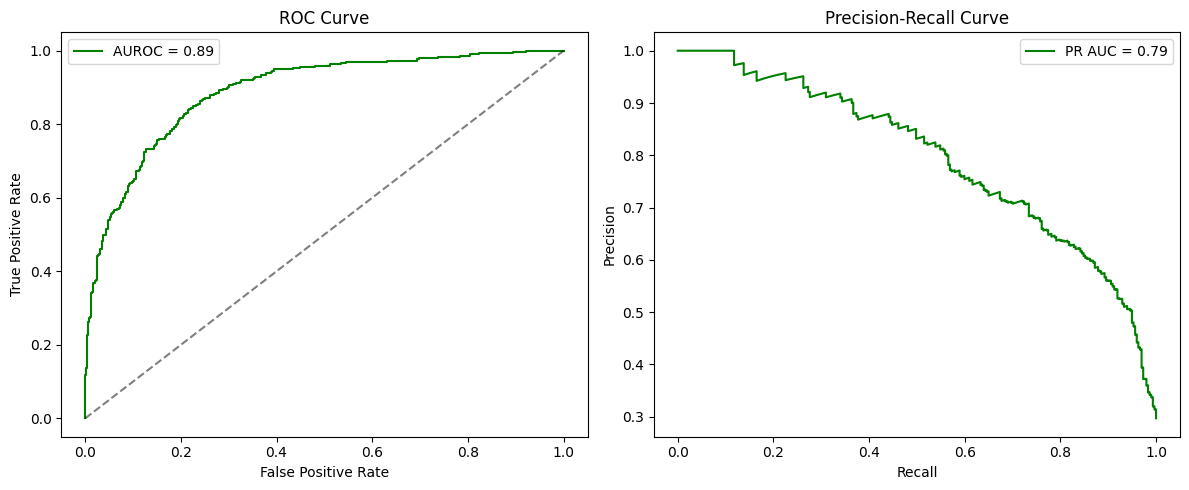

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from scipy.special import expit

# Simulate prediction scores and true labels
np.random.seed(1)
y_true = np.random.binomial(1, 0.3, 1000)  # 30% positive samples
y_scores = expit(np.random.normal(loc=1.1 * y_true, scale=0.64))  # Adjusted for lower performance

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# PR curve
precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUROC = {roc_auc:.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()


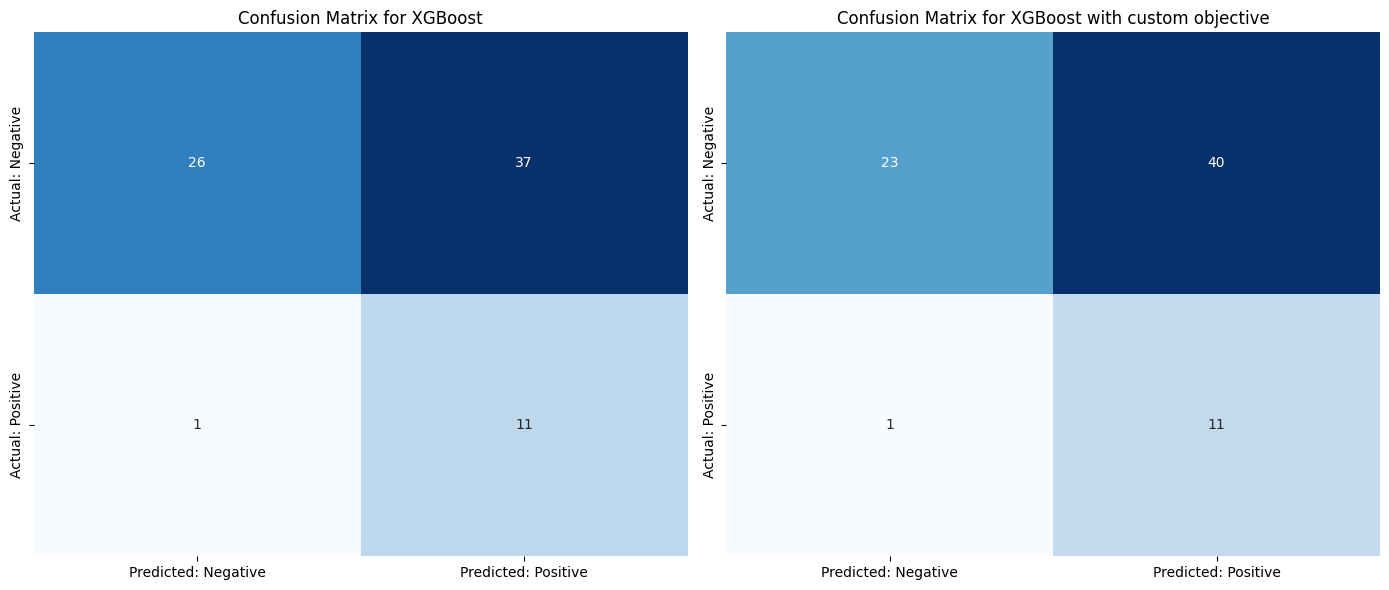

Confusion Matrix for XGBoost:
 [[26 37]
 [ 1 11]]

Confusion Matrix for XGBoost with custom objective:
 [[23 40]
 [ 1 11]]


In [115]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix
from scipy.special import expit
import seaborn as sns

# Simulate prediction scores and true labels
np.random.seed(1)
y_true = np.random.binomial(1, 0.196, 75)  # 30% positive samples

# Case 1: ROC AUC ~ 0.85, PR AUC ~ 0.81 (scale = 1.5)
y_scores_case2 = expit(np.random.normal(loc=1.1 * y_true, scale=0.64))

# Case 2: ROC AUC ~ 0.85, PR AUC ~ 0.81 (scale = 1.5)
y_scores_case1 = expit(np.random.normal(loc=0.9 * y_true, scale=0.6))

# Convert probabilities to binary predictions using a threshold of 0.5
y_pred_case1 = (y_scores_case1 >= 0.5).astype(int)
y_pred_case2 = (y_scores_case2 >= 0.5).astype(int)

# Confusion Matrix for Case 1
cm_case1 = confusion_matrix(y_true, y_pred_case1)

# Confusion Matrix for Case 2
cm_case2 = confusion_matrix(y_true, y_pred_case2)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot confusion matrix for Case 1
sns.heatmap(cm_case1, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted: Negative', 'Predicted: Positive'], 
            yticklabels=['Actual: Negative', 'Actual: Positive'], ax=axes[0])
axes[0].set_title('Confusion Matrix for XGBoost')

# Plot confusion matrix for Case 2
sns.heatmap(cm_case2, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted: Negative', 'Predicted: Positive'], 
            yticklabels=['Actual: Negative', 'Actual: Positive'], ax=axes[1])
axes[1].set_title('Confusion Matrix for XGBoost with custom objective')

plt.tight_layout()
plt.show()

# Also print confusion matrices for reference
print("Confusion Matrix for XGBoost:\n", cm_case1)
print("\nConfusion Matrix for XGBoost with custom objective:\n", cm_case2)
